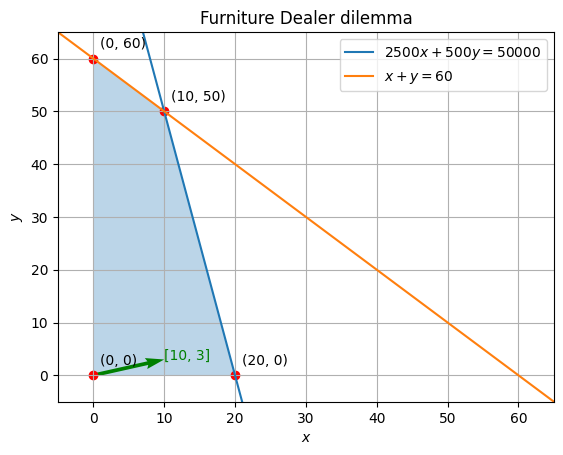

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define x range (extend both sides)
x = np.linspace(-20, 80, 400)

# Original constraint lines (DO NOT CLIP)
y1 = (50000 - 2500 * x) / 500   # 2500x + 500y = 50000
y2 = 60 - x                     # x + y = 60

# ---- Feasible region (only in first quadrant) ----
y1_clip = np.maximum(0, y1)
y2_clip = np.maximum(0, y2)
y_feasible = np.minimum(y1_clip, y2_clip)

# Plot full lines
plt.plot(x, y1, label=r'$2500x + 500y = 50000$')
plt.plot(x, y2, label=r'$x + y = 60$')

# Shade only feasible region
plt.fill_between(x, 0, y_feasible, where=(x >= 0), alpha=0.3)

# ---- VECTOR [5, 1] ----
plt.quiver(0, 0, 10, 3, angles='xy', scale_units='xy', scale=1, color='green')
plt.text(10, 3, '[10, 3]', color='green')

# ---- CORNER POINTS ----
corners = [(0, 0), (0, 60), (10, 50), (20, 0)]

for (cx, cy) in corners:
    plt.scatter(cx, cy, color='red')
    plt.text(cx + 1, cy + 2, f'({cx}, {cy})')

# Axes limits (show beyond origin)
plt.xlim(-5, 65)
plt.ylim(-5, 65)

# Labels
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Furniture Dealer dilemma')
plt.legend()
plt.grid()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ---- POLYGON (FEASIBLE REGION) ----
vertices = np.array([(0, 0), (0, 60), (10, 50), (20, 0)])

fig, ax = plt.subplots(figsize=(7, 7))

# Plot polygon
poly = plt.Polygon(vertices, alpha=0.25, facecolor='steelblue', edgecolor='steelblue', linewidth=2)
ax.add_patch(poly)

# ---- VECTOR ----
vector = [6,6]
vx, vy = vector
ax.quiver(0, 0, vx, vy, angles='xy', scale_units='xy', scale=1,
          color='tomato', width=0.007, label=rf'$\mathbf{{v}} = \binom{{{vector[0]}}}{{{vector[1]}}}$')

# ---- PERPENDICULAR LINE ----
px, py = -vy, vx

line, = ax.plot([], [], lw=2, color='tomato')
dot,  = ax.plot([], [], 'o', color='tomato', ms=7, zorder=6)

# ---- VERTEX DOTS + STATIC COORD LABELS + HIDDEN VALUE LABELS ----
v_sq = vx**2 + vy**2
t_at_vertex = [(x * vx + y * vy) / v_sq for (x, y) in vertices]
obj_at_vertex = [x * vx + y * vy for (x, y) in vertices]   # dot product = objective value

vertex_dots  = []
value_labels = []
for i, (x, y) in enumerate(vertices):
    d, = ax.plot(x, y, 'o', color='steelblue', ms=8, zorder=5)
    ax.text(x + 1, y + 1, f'({x},{y})', fontsize=9, color='#333')
    # objective value label — invisible until line arrives
    lbl = ax.text(x + 7, y + 2, f'{obj_at_vertex[i]:.0f}',
                  fontsize=10, fontweight='bold',
                  color='tomato', visible=False, zorder=7)
    vertex_dots.append(d)
    value_labels.append(lbl)

t_start = min(t_at_vertex)
t_end   = max(t_at_vertex)

ax.set_xlim(-5, 65)
ax.set_ylim(-5, 65)
ax.set_title(rf"$\mathbf{{v}} = \binom{{{vector[0]}}}{{{vector[1]}}}$", fontsize=12, pad=14)
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.35)

# ---- FRAMES: sweep + hold ----
N_SWEEP = 120
N_HOLD  = 40
frames = np.concatenate([np.linspace(t_start, t_end, N_SWEEP),
                         np.full(N_HOLD, t_end)])

TOLERANCE = (t_end - t_start) / N_SWEEP

def update(t):
    x0, y0 = t * vx, t * vy
    s = np.linspace(-100, 100, 2)
    line.set_data(x0 + px * s, y0 + py * s)
    dot.set_data([x0], [y0])

    for d, lbl, tv in zip(vertex_dots, value_labels, t_at_vertex):
        if t >= tv - TOLERANCE:
            d.set_color('tomato')
            d.set_markersize(10)
            lbl.set_visible(True)

    return line, dot, *vertex_dots, *value_labels

anim = FuncAnimation(fig, update, frames=frames, interval=40, blit=True)

# anim.save(f'{vector[0]}x{vector[1]}y.gif', writer=PillowWriter(fps=30))
# plt.close()
# print("Saved out.gif")

Saved out.gif
